In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from twelvedata import TDClient

TICKER = "GOLD"
START_TIME = "2020-01-01"
END_TIME = "2025-12-31"

df= yf.download(TICKER,start=START_TIME,end=END_TIME)

df.columns = df.columns.droplevel(1)

CAPITAL = 10000
#MOVING AVERAGE STRATEGY
fast =5
slow = 200
std = 2
sma=20
def moving_average(df,fast,slow):
    data =df.copy()
    df[f"{fast}_ma"] = df["Close"].rolling(fast).mean()
    df[f"{slow}_ma"] = df["Close"].rolling(slow).mean()
    
    df["Signal_moving_average"] = np.where(df[f"{fast}_ma"]>df[f"{slow}_ma"],1,-1)
    df["Position_moving_average"] = df["Signal_moving_average"].shift(1)
    df = df.dropna()

    df["Returns_moving_average"] = df["Close"].pct_change()
    df["Strategy_return_moving_average"] = df["Position_moving_average"] * df["Returns_moving_average"]
    
    df = df.dropna()
    
    df["Equity_curve_moving_average"] = (1+ df["Strategy_return_moving_average"]).cumprod()
    df["Portfolio_value_moving_average"] = CAPITAL*df["Equity_curve_moving_average"] 
    return df



def Bolliger_bands(df,std,sma): 
    df["20_sma"] = df["Close"].rolling(sma).mean()
    df["BB_STD"] = df["Close"].rolling(sma).std()
    
    df["upper_Band"] = df["20_sma"] + (std*df["BB_STD"])
    df["lower_Band"] = df["20_sma"] - (std*df["BB_STD"])
    df["signal_bolliger_bands"] = np.where(df["Close"].shift(1) < df["lower_Band"],1,
                                           np.where(df["Close"].shift(1) < df["upper_Band"],-1,0))
    df["Position_bolliger_bands"] = df["signal_bolliger_bands"].shift(1)
    df["Returns"] = df["Close"].pct_change()
    df["Strategy_return_bolliger_bands"] = df["Position_bolliger_bands"] * df["Returns"]
    
    df = df.dropna()
    
    df["Equity_curve_bolliger_bands"] = (1+ df["Strategy_return_bolliger_bands"]).cumprod()
    df["pnl_curve_bolliger_bands"] = (1+ df["Strategy_return_bolliger_bands"]).cumsum()

    df["Portfolio_value_bolliger_bands"] = CAPITAL*df["Equity_curve_bolliger_bands"] 
    
    df = df.dropna()
    return df
    df["day_of_week"] = df.index.day
    
    
    return df

def will_strategy(df):
    c1l = df["Open"] > df["Close"].shift(1)
    c2l = df["High"] > df["High"].shift(1)
    c3l = df["Low"] < df["Low"].shift(1)
    c4l = df["Close"] < df["Low"].shift(1)

    c1s = df["Open"] < df["Close"].shift(1)
    c2s = df["High"] < df["High"].shift(1)
    c3s = df["Low"] > df["Low"].shift(1)
    c4s = df["Close"] > df["Low"].shift(1)
    
    df["full_signal_two"] = np.where((c1l & c2l & c3l & c4l),
                   1,
                   np.where(
                       (c1s & c2s & c3s & c4s),
                   -1
                   ,0
                   )
                   )

    df["position_will_strategy"] =  df["full_signal_two"].shift(1)
    
    return df

def full_strategy(df):
    df["full_signal"] =   np.where(
                                    (
                                      (df["Position_moving_average"] == 1) & 
                                      (df["Position_bolliger_bands"] == 1)&
                                      (df["position_will_strategy"] == 1)
                                    ),
                                    1,
                                  np.where(
                                      (
                                          (df["Position_moving_average"] == -1)& 
                                          (df["Position_bolliger_bands"] == -1)&
                                          (df["position_will_strategy"] == -1)
                                        ),
                                        -1,
                                        0
                                      )
                                  )
    df["Returns"] = df["Close"].pct_change()
    df["full_strategy_returns"] = df["Returns"]*df["full_signal"].shift(1)
    
    df["Equity_curve_full_strategy"] = (1+df["full_strategy_returns"] ).cumprod()
    df["pnl_full_strategy"] = (1+df["full_strategy_returns"] ).cumsum()
    
    df["Portfolio_full_strategy"] = CAPITAL  * df["full_strategy_returns"]
    
    return df

    

[*********************100%***********************]  1 of 1 completed


In [5]:
df_copy = df.copy()
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,3.081281,3.151994,3.081281,3.151994,5400
2020-01-03,3.099335,3.321254,3.070373,3.321254,29200
2020-01-06,3.121903,3.287402,3.079400,3.193369,87200
2020-01-07,3.095574,3.366390,3.095574,3.287402,69400
2020-01-08,3.148233,3.193369,3.125665,3.148233,9000


In [9]:

print(len(df["Volume"] == 0))
print(len(df))

print(len(df["Close"] == 0))
print(len(df))

1288
1288
1288
1288


In [7]:

df = moving_average(df,fast,slow)
df = Bolliger_bands(df,std,sma)
df = full_strategy(df)
df = day_filter(df)
#df = will_strategy(df)
df.tail()

KeyError: 'position_will_strategy'

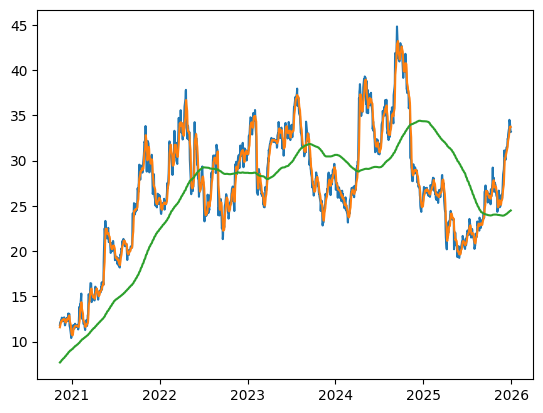

In [ ]:
plt.plot(df["Close"])
plt.plot(df[f"{fast}_ma"])
plt.plot(df[f"{slow}_ma"])

plt.show()

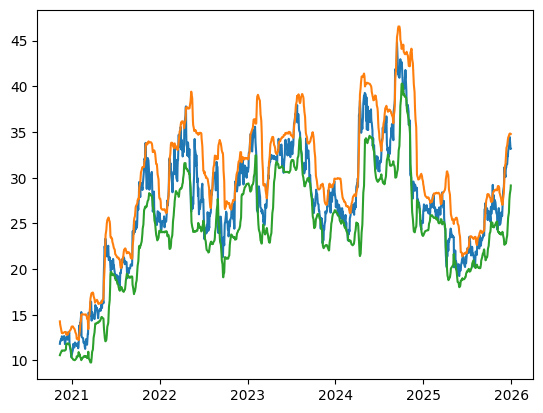

In [ ]:
plt.plot(df["Close"])
plt.plot(df["upper_Band"])
plt.plot(df["lower_Band"])

plt.show()

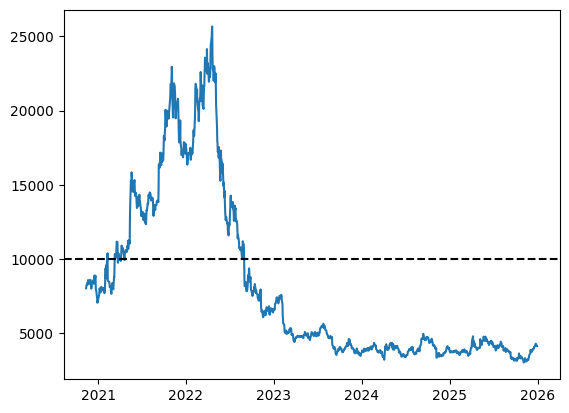

In [ ]:
plt.plot(df["Portfolio_value_moving_average"],label="Equity Curve")
plt.axhline(10000,linestyle="--",color="black")
plt.show()

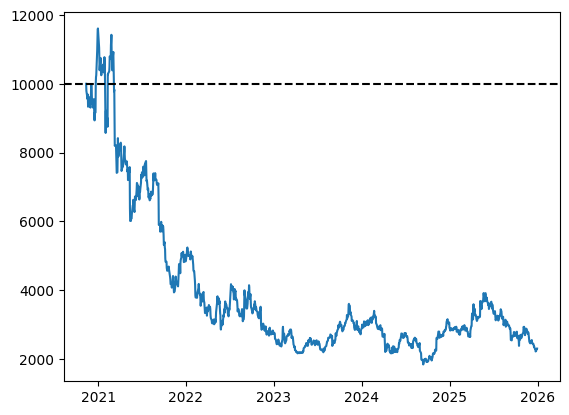

In [ ]:
plt.plot(df["Portfolio_value_bolliger_bands"],label="Equity Curve")
plt.axhline(10000,linestyle="--",color="black")
plt.show()

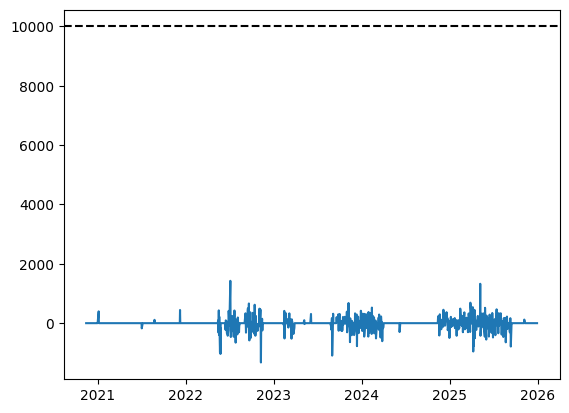

In [ ]:
plt.plot(df["Portfolio_full_strategy"],label="Equity Curve")
plt.axhline(10000,linestyle="--",color="black")
plt.show()

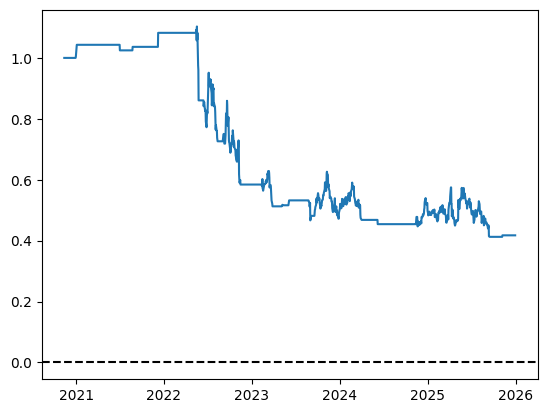

In [ ]:
plt.plot(df["Equity_curve_full_strategy"],label="Equity Curve")
plt.axhline(0,linestyle="--",color="black")
plt.show()

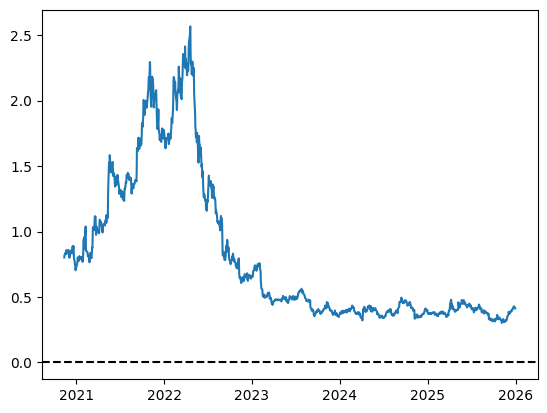

In [ ]:
plt.plot(df["Equity_curve_moving_average"],label="Equity Curve")
plt.axhline(0,linestyle="--",color="black")
plt.show()

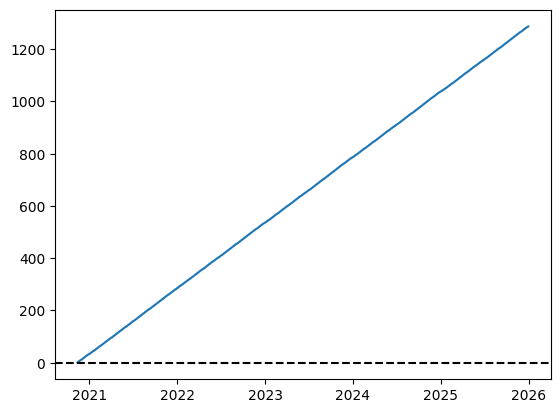

In [ ]:
plt.plot(df["pnl_curve_bolliger_bands"],label="Equity Curve")
plt.axhline(0,linestyle="--",color="black")
plt.show()

In [ ]:
def drawdown(df):
    df["Peak"] = df["Equity_curve"].cummax()
    df["Drawdown"] = (df["Equity_curve"] - df["Peak"])/df["Peak"]
    max_drawdown = df["Drawdown"].min()
    print("max_drawdown:",max_drawdown*100,"%")
    df = df.dropna()
    return df
df = drawdown(df)


plt.figure(figsize=(12,5))
plt.plot(df["Drawdown"],label="Drawdown")
plt.show()

#df.tail()

KeyError: 'Equity_curve'

In [ ]:
td = TDClient(apikey="6a16a146c01e69.32184220")

ts = td.time_series(
    symbol="CAD/USD",
    interval= "4h",
    outputsize=5000
)
df = ts.as_pandas()

import requests
from io import StringIO

response = requests.get("https://api.twelvedata.com/time_series?apikey=c8e59563113b46aca0f5694b85d3db91&interval=30min&symbol=EUR/USD&timezone=Africa/Nairobi&start_date=2011-01-03 10:13:00&format=CSV&previous_close=true&type=stock&dp=4&end_date=2026-05-26 10:15:00")



df = pd.read_csv(StringIO(response.text))
df.head()

InvalidApiKeyError: **apikey** parameter is incorrect or not specified. You can get your free API key instantly following this link: https://twelvedata.com/pricing. If you believe that everything is correct, you can contact us at https://twelvedata.com/contact/customer

In [ ]:
df.tail(1)

Price,Close,High,Low,Open,Volume,5_ma,200_ma,Signal_moving_average,Position_moving_average,Returns_moving_average,...,Equity_curve_bolliger_bands,pnl_curve_bolliger_bands,Portfolio_value_bolliger_bands,full_signal,full_strategy_returns,Equity_curve_full_strategy,pnl_full_strategy,Portfolio_full_strategy,Month,day_of_week
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-30,33.16795,33.604238,32.860562,33.485251,478900,33.711326,24.481257,1,1.0,0.000898,...,0.229618,1287.093026,2296.181501,0,0.0,0.417443,1286.31675,0.0,12,30


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from twelvedata import TDClient

TICKER = "EURUSD=X"
#START_TIME = "2024-01-01"
#END_TIME = "2025-12-31"
PERIOD = "1y"
INTERVAL = "4h"
CAPITAL = 10000
RISK = (10000*2)/100

df= yf.download(TICKER,period=PERIOD, interval =INTERVAL)

df.columns = df.columns.droplevel(1)
df2 = df

TP = (df2["Close"]+(df2["Close"]*4)/100)
SL = (df2["Close"]-(df2["Close"]*-2)/100)

def strategy(df2):
    c1l = df2["Open"] > df2["Close"].shift(1)
    c2l = df2["High"] > df2["High"].shift(1)
    c3l = df2["Low"] < df2["Low"].shift(1)
    c4l = df2["Close"] < df2["Low"].shift(1)

    c1s = df2["Open"] < df2["Close"].shift(1)
    c2s = df2["High"] < df2["High"].shift(1)
    c3s = df2["Low"] > df2["Low"].shift(1)
    c4s = df2["Close"] > df2["Low"].shift(1)
    
    df2["full_signal_two"] = np.where((c1l & c2l & c3l & c4l),
                   1,
                   np.where(
                       (c1s & c2s & c3s & c4s),
                   1
                   ,0
                   )
                   )

    df2["position"] =  df2["full_signal_two"].shift(1)
    return df2

df2 = strategy(df2)

def risk_logic(df2,RISK,TP,SL):
    
    df2["TP"] = TP
    df2["SL"] = SL
    
    
    return df2

df2 = risk_logic(df2,RISK,TP,SL)

def performance(df2):
    df2["returns"] = df2["Close"].pct_change()
    df2["strategy_returns"] = df2["position"] * df2["returns"] 
    #df2.loc[df2["strategy_returns"] == -0.000000,"strategy_returns" ] = 0.000000
    
    df2["equity_curve"] = (1+df2["strategy_returns"] ).cumprod()
    df2["pnl_curve"] = (1+df2["strategy_returns"] ).cumsum()
    df["Portfolio_full_strategy"] = (CAPITAL  * df["strategy_returns"]).cumsum()
    
    df2["WINRATE"] = np.where((df2["strategy_returns"] > 0.000001),1,0)
    totallong = len(df.loc[df["position"]== 1])
    totalshort = len(df.loc[df["position"]== 0])
    
    totaltrades = totallong + totalshort
    print(((len(df2["WINRATE"] == 1))/totaltrades)*100)
    #df2.loc[df["Equity_curve"] == -0.0,"equity_curve" ] = 0.0
    df2 =df2.dropna()
    return df2 
df2 = performance(df2)

def drawdown(df2):
    df2["Peak"] = df2["equity_curve"].cummax()
    df2["Drawdown"] = (df2["equity_curve"] - df2["Peak"])/df2["Peak"]
    max_drawdown = df2["Drawdown"].min()
    print("max_drawdown:",max_drawdown*100,"%")
    df2 = df2.dropna()
    return df2

df = drawdown(df2)

df2 =df2.dropna()
df.loc[df["WINRATE"]== 0]

[*********************100%***********************]  1 of 1 completed


100.06406149903908
max_drawdown: -2.179124719180503 %


Price,Close,High,Low,Open,Volume,full_signal_two,position,TP,SL,returns,strategy_returns,equity_curve,pnl_curve,Portfolio_full_strategy,WINRATE,Peak,Drawdown
Datetime,,,,,,,,,,,,,,,,,
2025-05-28 15:00:00+00:00,1.129816,1.131094,1.128796,1.130582,0,0,0.0,1.175008,1.152412,-0.000678,-0.000000,1.000000,1.000000,0.000000,0,1.0,0.000000
2025-05-28 19:00:00+00:00,1.129433,1.130071,1.129178,1.129688,0,1,0.0,1.174610,1.152022,-0.000339,-0.000000,1.000000,2.000000,0.000000,0,1.0,0.000000
2025-05-28 23:00:00+00:00,1.125113,1.129433,1.121957,1.129433,0,0,1.0,1.170117,1.147615,-0.003825,-0.003825,0.996175,2.996175,-38.253727,0,1.0,-0.003825
2025-05-29 03:00:00+00:00,1.127396,1.127650,1.123469,1.124859,0,1,0.0,1.172491,1.149944,0.002029,0.000000,0.996175,3.996175,-38.253727,0,1.0,-0.003825
2025-05-29 11:00:00+00:00,1.135332,1.136364,1.127142,1.128923,0,0,0.0,1.180745,1.158038,0.005677,0.000000,0.997524,5.997529,-24.705434,0,1.0,-0.002476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-27 19:00:00+00:00,1.162926,1.164009,1.162926,1.163332,0,0,0.0,1.209443,1.186184,-0.000349,-0.000000,0.979807,1556.979706,-202.938017,0,1.0,-0.020193
2026-05-27 23:00:00+00:00,1.161575,1.163332,1.161305,1.162926,0,0,0.0,1.208038,1.184807,-0.001162,-0.000000,0.979807,1557.979706,-202.938017,0,1.0,-0.020193
2026-05-28 03:00:00+00:00,1.161440,1.161710,1.159017,1.161575,0,0,0.0,1.207898,1.184669,-0.000116,-0.000000,0.979807,1558.979706,-202.938017,0,1.0,-0.020193


In [ ]:
print(SL)

Datetime
2025-05-28 11:00:00+00:00    1.153194
2025-05-28 15:00:00+00:00    1.152412
2025-05-28 19:00:00+00:00    1.152022
2025-05-28 23:00:00+00:00    1.147615
2025-05-29 03:00:00+00:00    1.149944
                               ...   
2026-05-27 19:00:00+00:00    1.186184
2026-05-27 23:00:00+00:00    1.184807
2026-05-28 03:00:00+00:00    1.184669
2026-05-28 07:00:00+00:00    1.183981
2026-05-28 11:00:00+00:00    1.187013
Name: Close, Length: 1562, dtype: float64


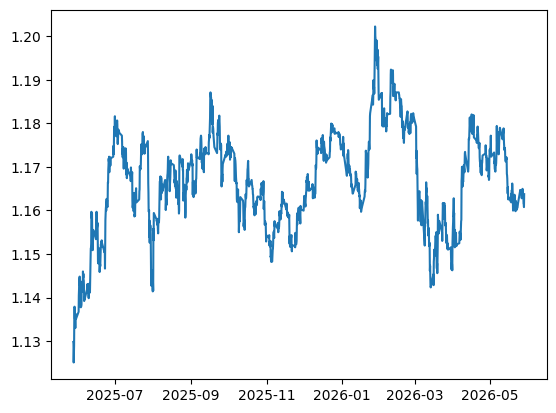

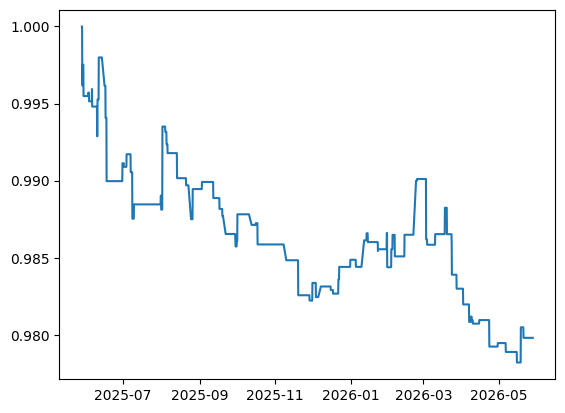

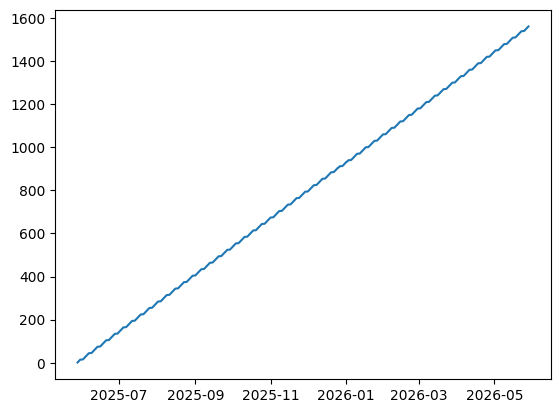

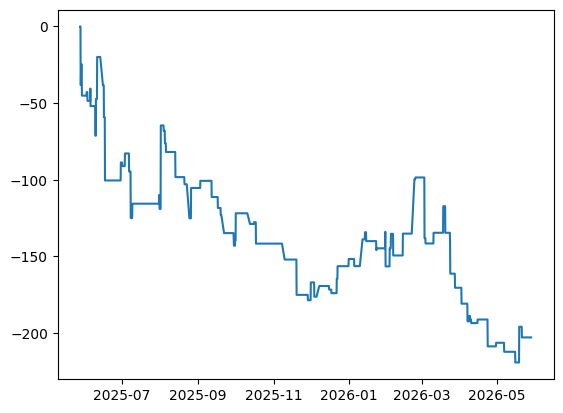

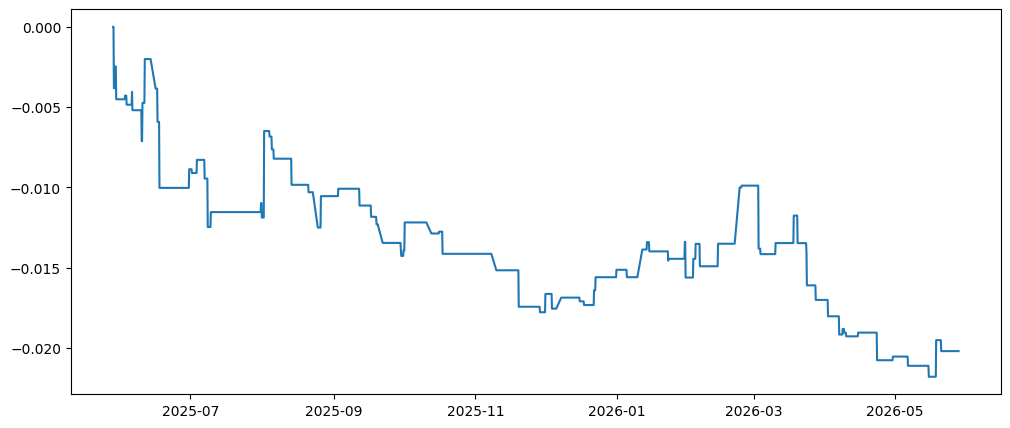

long: 91
short: 0
no: 1470


In [ ]:
plt.plot(df["Close"])
plt.show()


plt.plot(df2["equity_curve"])
plt.show()

plt.plot(df2["pnl_curve"],label = "pnl")
plt.show()

plt.plot(df["Portfolio_full_strategy"])
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["Drawdown"],label="Drawdown")
plt.show()

print("long:",len(df.loc[df["position"]== 1]))
print("short:",len(df.loc[df["position"]== -1]))
print("no:",len(df.loc[df["position"]== 0]))
